<a href="https://colab.research.google.com/github/AbhishekShah272002/Gen_AI_Computer_Vision_Work/blob/main/CNN_Feature_Maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1809s 11us/step


In [ ]:
input_layer = Input(shape=(32, 32, 3))
x = Conv2D(32, (3,3), activation='relu', name='conv1')(input_layer)
x = MaxPooling2D((2,2), name='pool1')(x)
x = Conv2D(64, (3,3), activation='relu', name='conv2')(x)
x = MaxPooling2D((2,2), name='pool2')(x)
x = Flatten()(x)
output_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4814 - loss: 1.4548 - val_accuracy: 0.5674 - val_loss: 1.2163
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6111 - loss: 1.1162 - val_accuracy: 0.6096 - val_loss: 1.0820
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6560 - loss: 0.9980 - val_accuracy: 0.6355 - val_loss: 1.0302


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step


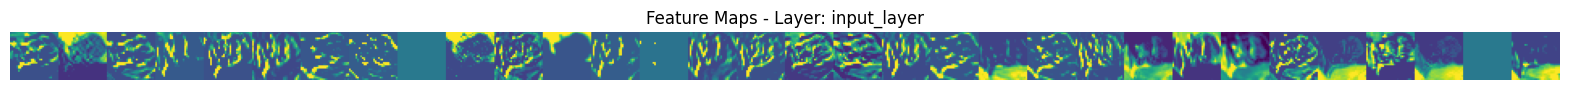

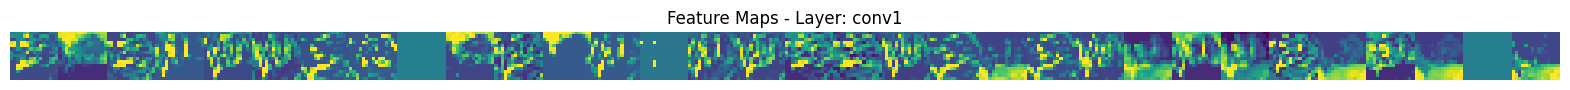

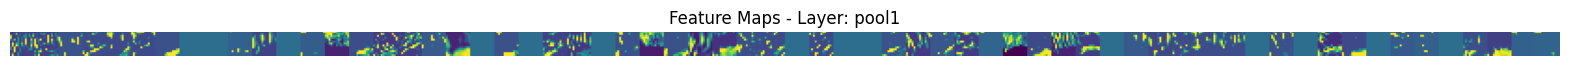

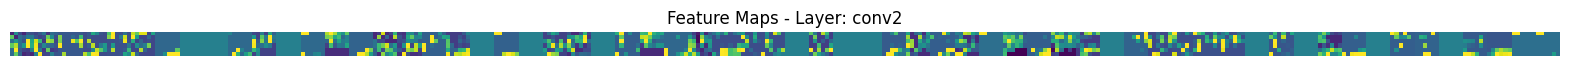

In [ ]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name or 'pool' in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Select a single image from the test set and add a batch dimension
image_input = np.expand_dims(x_test[0], axis=0)

activations = activation_model.predict(image_input)

for layer_name, activation in zip([layer.name for layer in activation_model.layers], activations):
    n_features = activation.shape[-1]  # number of channels
    size = activation.shape[1]         # width/height of feature map

    display_grid = np.zeros((size, size * n_features))

    for i in range(n_features):
        feature_map = activation[0, :, :, i]
        feature_map -= feature_map.mean()
        feature_map /= (feature_map.std() + 1e-5)
        feature_map *= 64
        feature_map += 128
        feature_map = np.clip(feature_map, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = feature_map

    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(f'Feature Maps - Layer: {layer_name}')
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Reshape

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

input_layer = Input(shape=(28, 28, 1))
x = Conv2D(8, (3,3), activation='relu', name='conv1')(input_layer)
x = MaxPooling2D((2,2), name='pool1')(x)
x = Conv2D(16, (3,3), activation='relu', name='conv2')(x)
x = MaxPooling2D((2,2), name='pool2')(x)
x = Flatten()(x)
output_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

# Load the data if x_test is not defined (e.g., if kernel was restarted or previous cells were not run)
if 'x_test' not in locals() and 'x_test' not in globals():
    print("x_test not found, loading MNIST data and preprocessing for x_test.")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_test = x_test.astype('float32') / 255.0
    x_test = x_test.reshape((-1, 28, 28, 1))

image = x_test[0]  # Digit image
image_input = np.expand_dims(image, axis=0)

In [ ]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name or 'pool' in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

In [ ]:
activations = activation_model.predict(image_input)
